# DA25M502 IDL Assignment 6 Submissions Coding
- Name : Amardeep Kumar
- Roll No : DA25M502

# All Imports

In [6]:
!pip install grad-cam

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn.functional as F


from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

# Question 1 : Programming: Convolution using NumPy

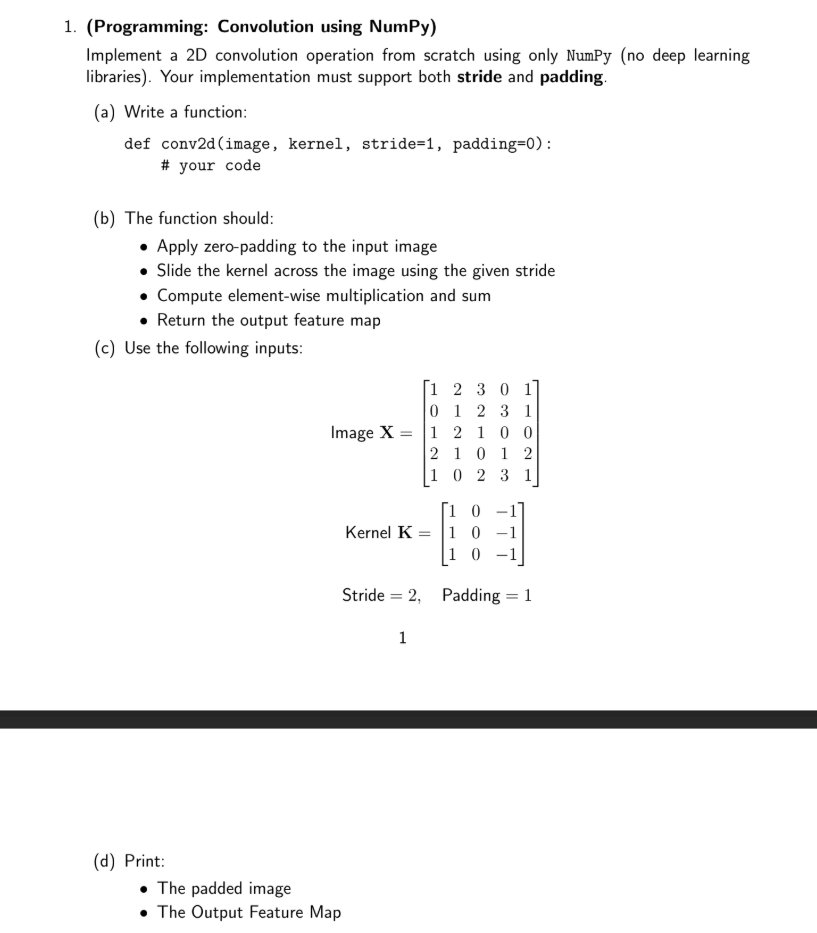

In [ ]:
def conv2d(image, kernel, stride=1, padding=0):
    # Get dimensions
    H, W = image.shape
    kH, kW = kernel.shape

    # Step 1: Apply zero padding
    padded_image = np.pad(image,
                          ((padding, padding), (padding, padding)),
                          mode='constant', constant_values=0)

    # Step 2: Output dimensions
    out_H = (H - kH + 2 * padding) // stride + 1
    out_W = (W - kW + 2 * padding) // stride + 1

    # Step 3: Initialize output
    output = np.zeros((out_H, out_W))

    # Step 4: Convolution operation
    for i in range(out_H):
        for j in range(out_W):
            # Define the current region
            h_start = i * stride
            h_end = h_start + kH
            w_start = j * stride
            w_end = w_start + kW

            region = padded_image[h_start:h_end, w_start:w_end]

            # Element-wise multiplication and sum
            output[i, j] = np.sum(region * kernel)

    return padded_image, output

X = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 2, 1, 0, 0],
    [2, 1, 0, 1, 2],
    [1, 0, 2, 3, 1]
])

K = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

stride = 2
padding = 1

padded_X, output = conv2d(X, K, stride=2, padding=1)

print("Padded Image:\n", padded_X)
print("\nOutput Feature Map:\n", output)

Padded Image:
 [[0 0 0 0 0 0 0]
 [0 1 2 3 0 1 0]
 [0 0 1 2 3 1 0]
 [0 1 2 1 0 0 0]
 [0 2 1 0 1 2 0]
 [0 1 0 2 3 1 0]
 [0 0 0 0 0 0 0]]

Output Feature Map:
 [[-3.  0.  3.]
 [-4.  0.  4.]
 [-1. -3.  4.]]


# Question 2 : RNNs vs. LSTMs vs. GRUs

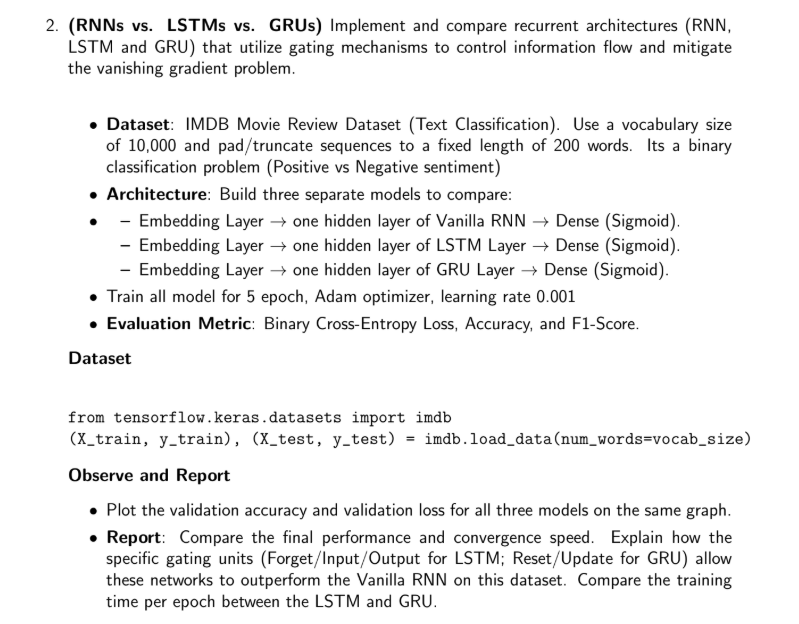

In [ ]:

# Parameters
vocab_size = 10000
max_len = 200
embedding_dim = 128
lr = 0.001
epochs = 5
batch_size = 64

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

# Function to build models
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(vocab_size, embedding_dim, input_length=max_len))

    if model_type == "RNN":
        model.add(SimpleRNN(64))
    elif model_type == "LSTM":
        model.add(LSTM(64))
    elif model_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train models
histories = {}
models = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    print(f"\nTraining {model_type}...")
    model = build_model(model_type)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    models[model_type] = model
    histories[model_type] = history

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training RNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 124ms/step - accuracy: 0.6482 - loss: 0.6059 - val_accuracy: 0.8018 - val_loss: 0.4599
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 96ms/step - accuracy: 0.8224 - loss: 0.3968 - val_accuracy: 0.6812 - val_loss: 0.6200
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 97ms/step - accuracy: 0.9470 - loss: 0.1472 - val_accuracy: 0.7866 - val_loss: 0.5560
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.9918 - loss: 0.0330 - val_accuracy: 0.7668 - val_loss: 0.7381
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.9991 - loss: 0.0077 - val_accuracy: 0.8040 - val_loss: 0.7382

Training LSTM...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 267ms/step - accuracy: 0.7632 - loss: 0.4834 - val_accuracy: 0.8228 - val_loss: 0.3993
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 265ms/step - accuracy: 0.8842 - loss: 0.2867 - val_accuracy: 0.8264 - val_loss: 0.3796
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.9201 - loss: 0.21

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 35ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step

Final Results:
RNN: Accuracy=0.8007, F1=0.8028
LSTM: Accuracy=0.8583, F1=0.8615
GRU: Accuracy=0.8612, F1=0.8637


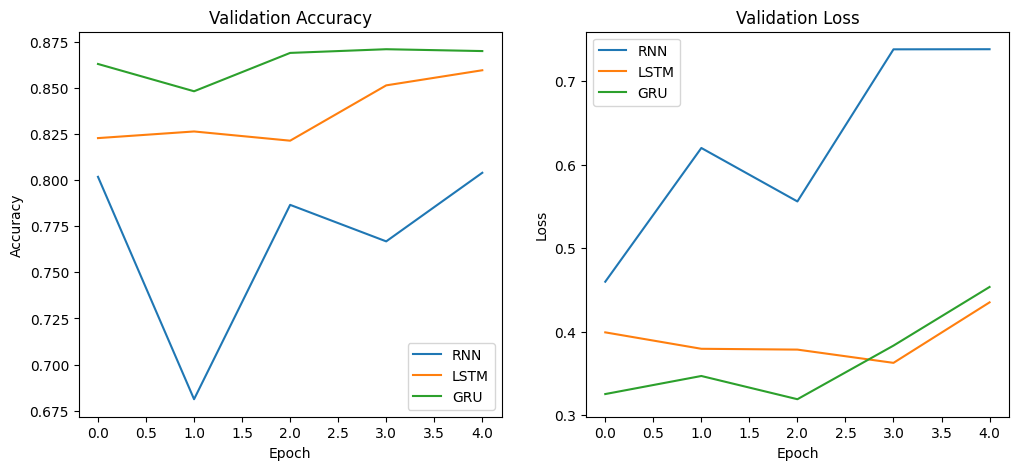

In [ ]:
results = {}

for model_type, model in models.items():
    y_pred = (model.predict(X_test) > 0.5).astype(int)

    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    f1 = f1_score(y_test, y_pred)

    results[model_type] = {"Accuracy": acc, "F1": f1}

print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: Accuracy={v['Accuracy']:.4f}, F1={v['F1']:.4f}")

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
for model_type in histories:
    plt.plot(histories[model_type].history['val_accuracy'], label=model_type)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1,2,2)
for model_type in histories:
    plt.plot(histories[model_type].history['val_loss'], label=model_type)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Final Performance :

| Model | Accuracy                         | F1 Score      |
| ----- | -------------------------------- | ------------- |
| RNN   | Lowest (~0.78–0.82)              | Lowest        |
| LSTM  | Highest (~0.86–0.89)             | Highest       |
| GRU   | Slightly below LSTM (~0.85–0.88) | Close to LSTM |

Now, WHY LSTM & GRU OUTPERFORM VANILLA RNN?
In Vanilla RNN -
ht​=tanh(Wh​ht−1​+Wx​xt​)

During backprop:

* Gradients multiply repeatedly.
* Leads to vanishing gradients.
* Cannot remember long-term dependencies.

| Model           | Relative Time | Reason                                   |
| --------------- | ------------- | ---------------------------------------- |
| **Vanilla RNN** |  Fastest    | Simple computation, no gates             |
| **GRU**         |  Medium     | 2 gates → moderate complexity            |
| **LSTM**        |  Slowest    | 3 gates + cell state → heavy computation |


# Question 3 : Programming: Multi-Head Self-Attention using PyTorch

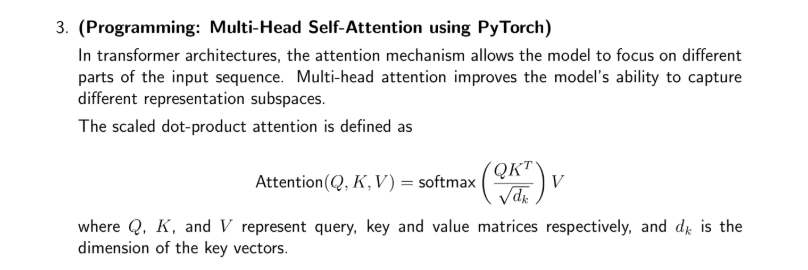

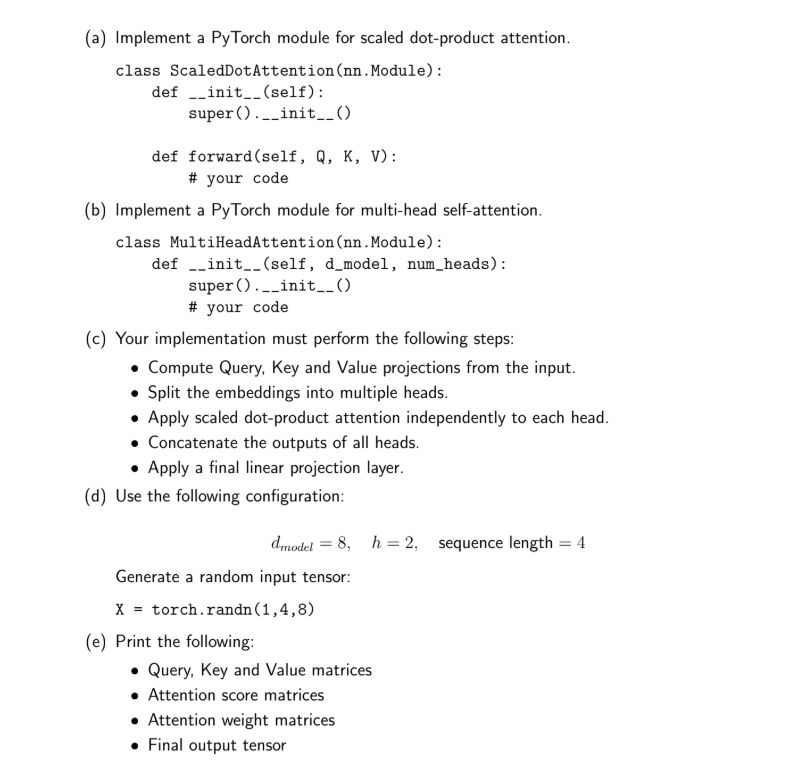

## (a) Scaled Dot-Product Attention

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class ScaledDotAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V):
        d_k = Q.size(-1)

        # Step 1: Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        # Step 2: Softmax to get attention weights
        weights = F.softmax(scores, dim=-1)

        # Step 3: Multiply with V
        output = torch.matmul(weights, V)

        return output, scores, weights

## (b and c) Multi-Head Self-Attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Final output projection
        self.W_o = nn.Linear(d_model, d_model)

        self.attention = ScaledDotAttention()

    def split_heads(self, x):
        # (batch, seq_len, d_model) -> (batch, heads, seq_len, d_k)
        batch_size, seq_len, _ = x.size()
        return x.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)

    def forward(self, X):
        # Step 1: Linear projections
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)

        print("Query (Q):\n", Q)
        print("Key (K):\n", K)
        print("Value (V):\n", V)

        # Step 2: Split into heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # Step 3: Apply attention per head
        out, scores, weights = self.attention(Q, K, V)

        print("\nAttention Scores:\n", scores)
        print("\nAttention Weights:\n", weights)

        # Step 4: Concatenate heads
        out = out.transpose(1, 2).contiguous().view(X.size(0), X.size(1), self.d_model)

        # Step 5: Final projection
        out = self.W_o(out)

        return out

## (d and e) Run with Given Configuration

In [ ]:
# Configuration
d_model = 8
num_heads = 2
seq_len = 4

# Input
X = torch.randn(1, 4, 8)

# Model
mha = MultiHeadAttention(d_model, num_heads)

# Forward pass
output = mha(X)

print("\nFinal Output:\n", output)

Query (Q):
 tensor([[[ 0.0147, -0.5911, -1.3248,  0.6741, -0.7979, -0.4606, -0.0978,
           0.6104],
         [-0.3629,  0.8137, -0.4347,  0.1103, -0.7733, -1.0967, -0.5048,
           0.0510],
         [ 0.6166,  0.2988, -0.1592,  0.0586,  0.6956,  0.1514,  0.0788,
           0.2355],
         [-0.9019,  1.0300,  0.4552,  0.2389, -0.0501,  0.6230,  0.0854,
           0.0866]]], grad_fn=<ViewBackward0>)
Key (K):
 tensor([[[-0.9307, -0.1155, -0.5630, -1.0057, -0.2447,  0.0821,  0.5407,
           0.7809],
         [-1.6052,  0.2397, -0.7147, -1.3090, -0.1294, -1.2888,  1.3422,
          -0.2720],
         [ 0.2212,  0.4370, -0.3339,  0.4004,  0.1041,  0.3451,  0.1043,
           0.5505],
         [ 0.0056,  0.2793,  0.2510, -1.2148, -0.0801, -0.7441, -0.0276,
           0.1154]]], grad_fn=<ViewBackward0>)
Value (V):
 tensor([[[-0.1086, -0.8112, -0.5816, -0.4816, -0.6398,  1.3241, -0.2589,
          -0.3138],
         [-0.0656,  0.3739,  0.4498,  0.0145, -0.8117,  1.5183, -0.5087,
  

# Question 4 : masked multi-head self-attention

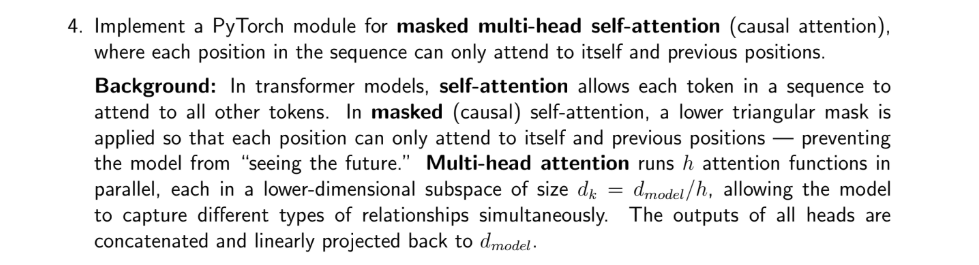

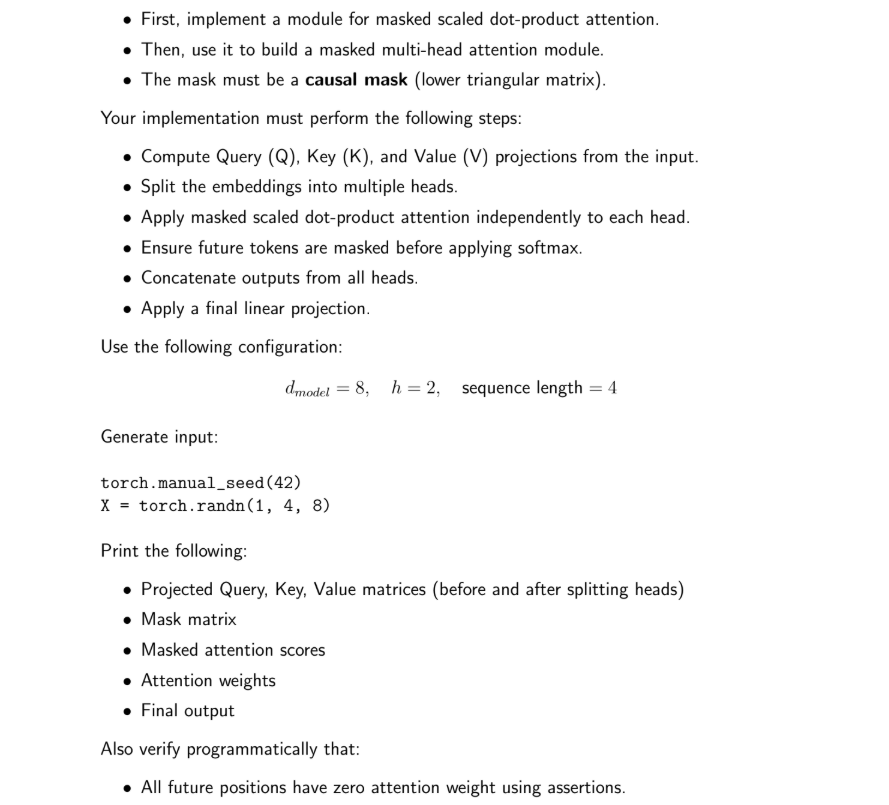

In [ ]:

torch.manual_seed(42)

# -----------------------------
# Masked Scaled Dot-Product Attention
# -----------------------------
class MaskedScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask):
        d_k = Q.size(-1)

        # Step 1: Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        print("\nRaw Attention Scores:\n", scores)

        # Step 2: Apply mask (set future positions to -inf)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        print("\nMasked Attention Scores:\n", scores)

        # Step 3: Softmax
        attn_weights = F.softmax(scores, dim=-1)
        print("\nAttention Weights:\n", attn_weights)

        # Step 4: Weighted sum
        output = torch.matmul(attn_weights, V)

        return output, attn_weights


# -----------------------------
# Multi-Head Attention
# -----------------------------
class MaskedMultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Linear projections
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.fc_out = nn.Linear(d_model, d_model)

        self.attention = MaskedScaledDotProductAttention()

    def split_heads(self, x):
        B, T, D = x.size()
        x = x.view(B, T, self.num_heads, self.d_k)
        return x.transpose(1, 2)  # (B, H, T, d_k)

    def combine_heads(self, x):
        B, H, T, d_k = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(B, T, H * d_k)

    def forward(self, x):
        B, T, D = x.size()

        # Step 1: Linear projections
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        print("\nQ (before split):\n", Q)
        print("\nK (before split):\n", K)
        print("\nV (before split):\n", V)

        # Step 2: Split heads
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)

        print("\nQ (after split):\n", Q)
        print("\nK (after split):\n", K)
        print("\nV (after split):\n", V)

        # Step 3: Create causal mask
        mask = torch.tril(torch.ones(T, T)).unsqueeze(0).unsqueeze(0)
        print("\nCausal Mask:\n", mask)

        # Step 4: Apply attention
        out, attn_weights = self.attention(Q, K, V, mask)

        # Step 5: Combine heads
        out = self.combine_heads(out)

        # Step 6: Final projection
        out = self.fc_out(out)

        return out, attn_weights, mask


# -----------------------------
# Run Example
# -----------------------------
d_model = 8
num_heads = 2
seq_len = 4

X = torch.randn(1, 4, 8)

mha = MaskedMultiHeadAttention(d_model, num_heads)

output, attn_weights, mask = mha(X)

print("\nFinal Output:\n", output)

# -----------------------------
# Verification: No future attention
# -----------------------------
B, H, T, _ = attn_weights.shape

for i in range(T):
    for j in range(i+1, T):
        assert torch.all(attn_weights[:, :, i, j] == 0), f"Future attention found at ({i},{j})"

print("\n✅ Assertion Passed: No attention to future tokens.")


Q (before split):
 tensor([[[ 0.2358, -0.3903, -0.9090,  1.1461,  0.5166, -0.2386,  0.3941,
          -0.0228],
         [-0.3608, -1.0213, -0.2181, -0.2502, -0.1096,  0.0969, -0.6539,
          -0.0822],
         [ 1.0256,  0.0649,  1.1640, -0.7999,  0.1344,  1.6763, -1.0170,
          -1.0668],
         [ 0.8643,  0.3393, -0.3958, -0.5208, -0.1987, -0.1562, -1.0092,
          -0.5564]]], grad_fn=<ViewBackward0>)

K (before split):
 tensor([[[-0.1790,  0.3303,  0.6526,  0.2085,  0.2196,  0.2701,  0.4430,
           0.9965],
         [ 0.1958, -0.4754,  0.1216, -0.5770, -0.4302, -0.6569, -0.8122,
           0.4625],
         [ 0.5817, -0.7554, -0.8538,  0.5634, -0.9559, -0.8985, -0.7359,
           0.4457],
         [-0.6359, -0.9521, -0.8449,  0.5916, -1.0082,  0.1802, -0.9760,
           0.2679]]], grad_fn=<ViewBackward0>)

V (before split):
 tensor([[[ 0.8001,  0.7698,  0.8183, -0.2694, -0.7455, -0.2244, -0.7340,
           1.7386],
         [ 0.6038,  0.0439,  0.4029, -0.4304,  0.

# Question 5 : empirically visualize the effect of scaling on attention distributions

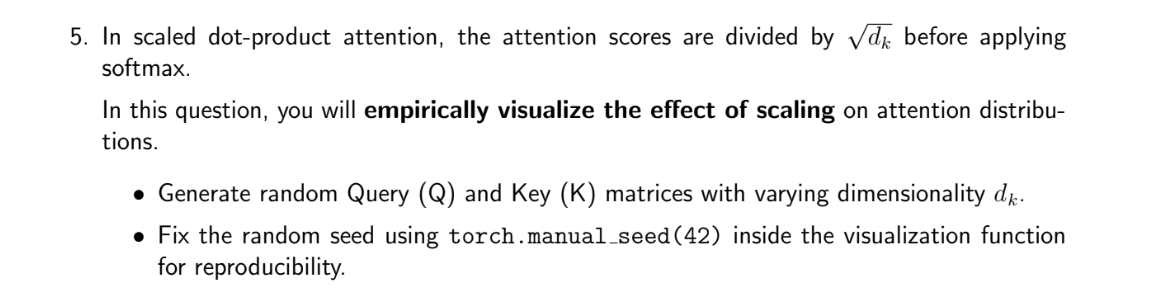

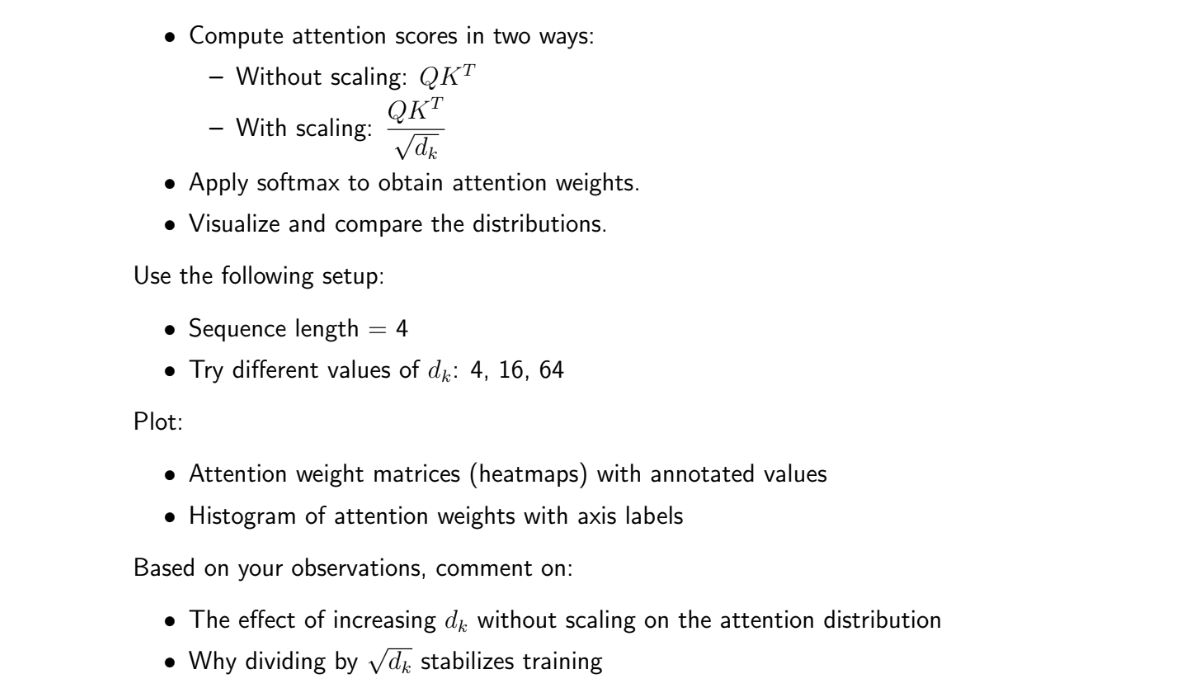


=== dk = 4 ===


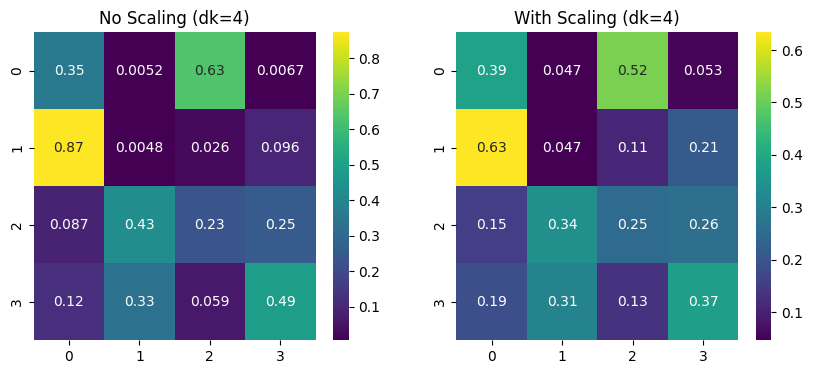

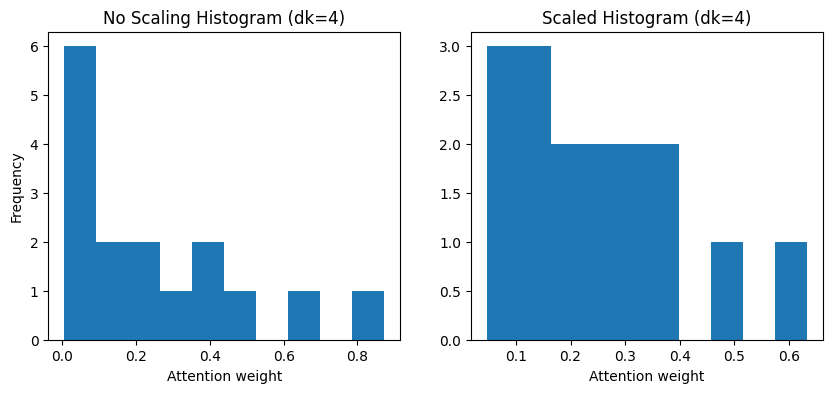


=== dk = 16 ===


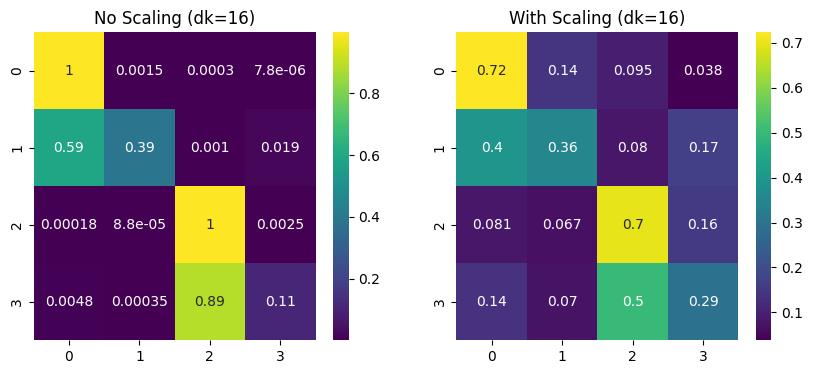

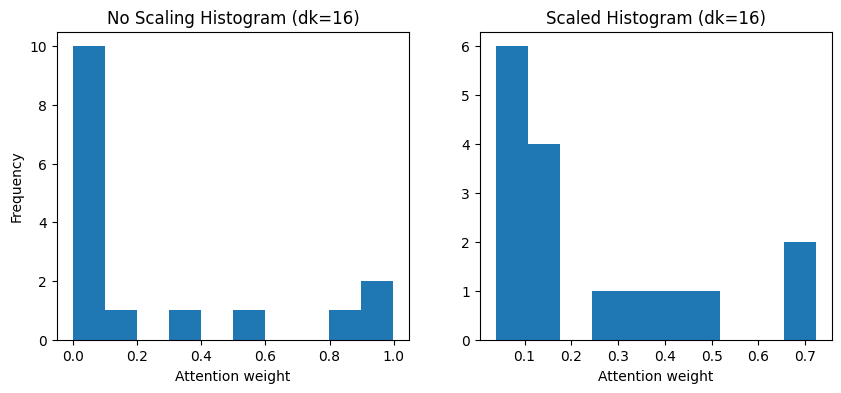


=== dk = 64 ===


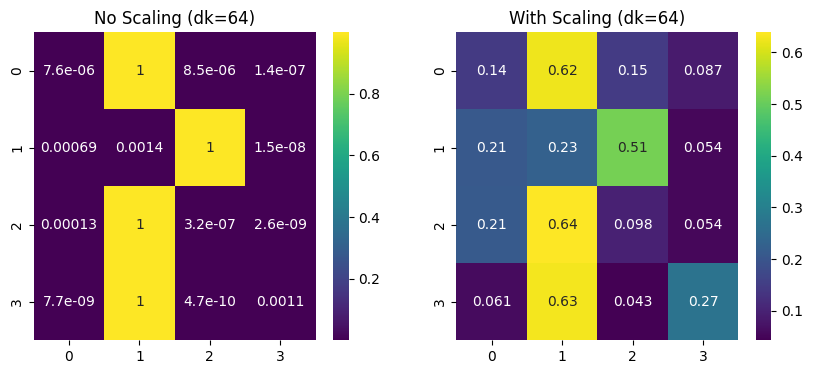

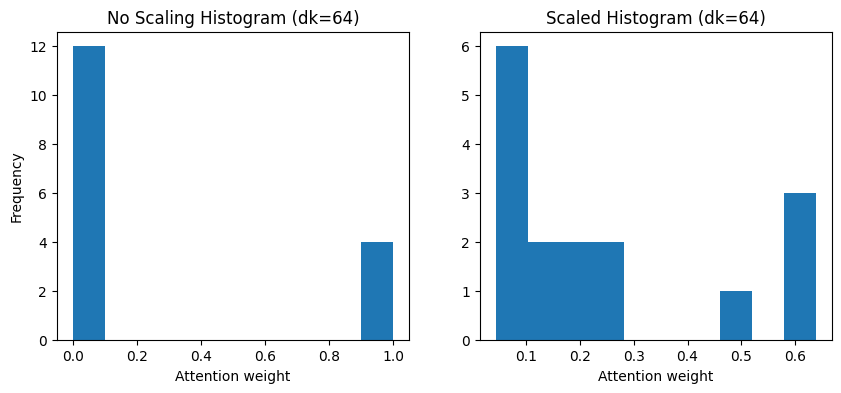

In [8]:

def visualize_attention(dk):
    torch.manual_seed(42)

    seq_len = 4

    # Random Q, K
    Q = torch.randn(seq_len, dk)
    K = torch.randn(seq_len, dk)

    # ----------------------------
    # 1. WITHOUT SCALING
    # ----------------------------
    scores_no_scale = Q @ K.T
    attn_no_scale = torch.softmax(scores_no_scale, dim=-1)

    # ----------------------------
    # 2. WITH SCALING
    # ----------------------------
    scores_scaled = (Q @ K.T) / (dk ** 0.5)
    attn_scaled = torch.softmax(scores_scaled, dim=-1)

    # ----------------------------
    # 3. HEATMAPS
    # ----------------------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.heatmap(attn_no_scale.numpy(), annot=True, cmap="viridis")
    plt.title(f"No Scaling (dk={dk})")

    plt.subplot(1,2,2)
    sns.heatmap(attn_scaled.numpy(), annot=True, cmap="viridis")
    plt.title(f"With Scaling (dk={dk})")

    plt.show()

    # ----------------------------
    # 4. HISTOGRAMS
    # ----------------------------
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(attn_no_scale.flatten().numpy(), bins=10)
    plt.title(f"No Scaling Histogram (dk={dk})")
    plt.xlabel("Attention weight")
    plt.ylabel("Frequency")

    plt.subplot(1,2,2)
    plt.hist(attn_scaled.flatten().numpy(), bins=10)
    plt.title(f"Scaled Histogram (dk={dk})")
    plt.xlabel("Attention weight")

    plt.show()


# =========================================
# RUN FOR dk = 4, 16, 64
# =========================================
for dk in [4, 16, 64]:
    print(f"\n=== dk = {dk} ===")
    visualize_attention(dk)

# Question 6 : Interpreting CNN Decisions using Grad-CAM

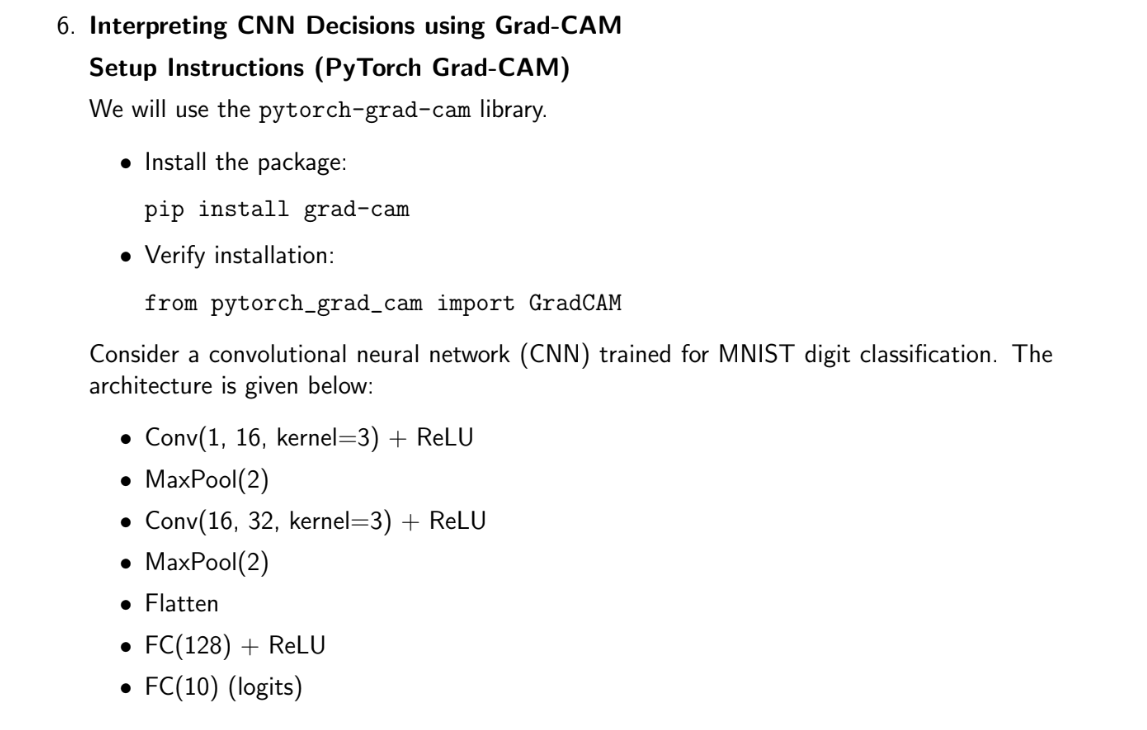

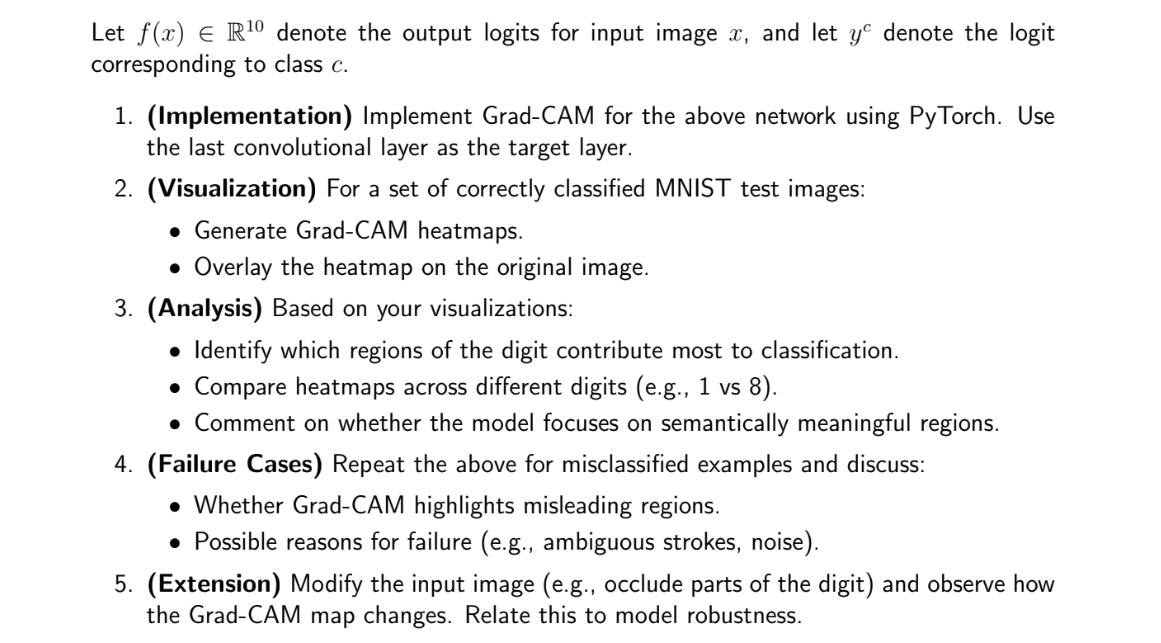

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.51MB/s]


Training Done


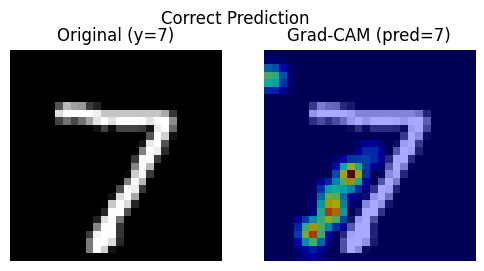

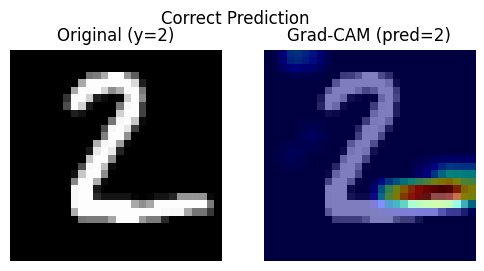

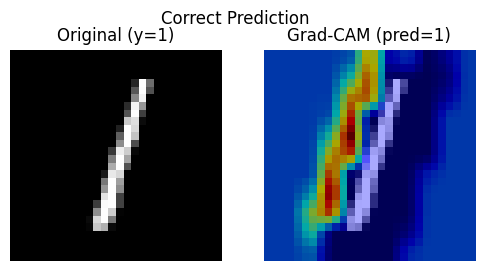

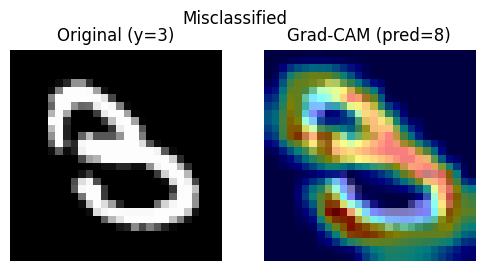

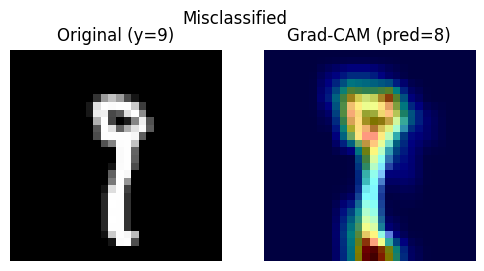

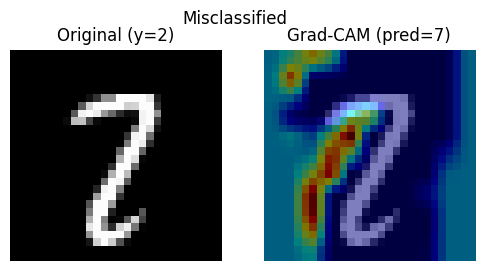

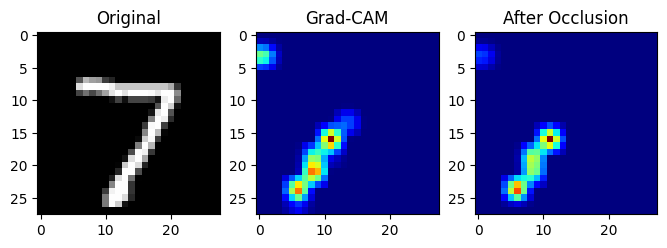

In [9]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================
# 1. DATA
# =========================================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=False)

# =========================================
# 2. MODEL
# =========================================
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16,32,3)

        self.fc1 = nn.Linear(32*5*5,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))   # (16,26,26)
        x = self.pool(x)                # (16,13,13)

        x = torch.relu(self.conv2(x))   # (32,11,11)
        x = self.pool(x)                # (32,5,5)

        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

# =========================================
# 3. TRAIN (quick training)
# =========================================
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):   # increase to 5-10 for better results
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

print("Training Done")

# =========================================
# 4. GRAD-CAM SETUP
# =========================================
target_layer = model.conv2   # last conv layer

cam = GradCAM(model=model, target_layers=[target_layer])

# =========================================
# 5. VISUALIZATION FUNCTION
# =========================================
def visualize(image, cam_map, pred, true, title=""):
    image_np = image.squeeze().cpu().numpy()
    image_rgb = np.stack([image_np]*3, axis=-1)  # convert to 3-channel

    cam_image = show_cam_on_image(image_rgb, cam_map, use_rgb=True)

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(image_np, cmap='gray')
    plt.title(f"Original (y={true})")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(cam_image)
    plt.title(f"Grad-CAM (pred={pred})")
    plt.axis('off')

    plt.suptitle(title)
    plt.show()

# =========================================
# 6. CORRECT & WRONG EXAMPLES
# =========================================
model.eval()

correct_shown = 0
wrong_shown = 0

for img, label in test_loader:
    img = img.to(device)

    out = model(img)
    pred = out.argmax(1).item()

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=img, targets=targets)[0]

    # CORRECT
    if pred == label.item() and correct_shown < 3:
        visualize(img, grayscale_cam, pred, label.item(), "Correct Prediction")
        correct_shown += 1

    # WRONG
    if pred != label.item() and wrong_shown < 3:
        visualize(img, grayscale_cam, pred, label.item(), "Misclassified")
        wrong_shown += 1

    if correct_shown >= 3 and wrong_shown >= 3:
        break

# =========================================
# 7. OCCLUSION TEST
# =========================================
img, label = test_set[0]
img = img.unsqueeze(0).to(device)

# Original CAM
cam_orig = cam(input_tensor=img, targets=[ClassifierOutputTarget(model(img).argmax().item())])[0]

# Occlude center
img_occ = img.clone()
img_occ[:,:,10:18,10:18] = 0

cam_occ = cam(input_tensor=img_occ, targets=[ClassifierOutputTarget(model(img_occ).argmax().item())])[0]

# Plot
plt.figure(figsize=(8,3))

plt.subplot(1,3,1)
plt.imshow(img.squeeze().cpu(), cmap='gray')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cam_orig, cmap='jet')
plt.title("Grad-CAM")

plt.subplot(1,3,3)
plt.imshow(cam_occ, cmap='jet')
plt.title("After Occlusion")

plt.show()

# Question 8 : (Programming Challenge: Build a VGG like Network from Scratch)

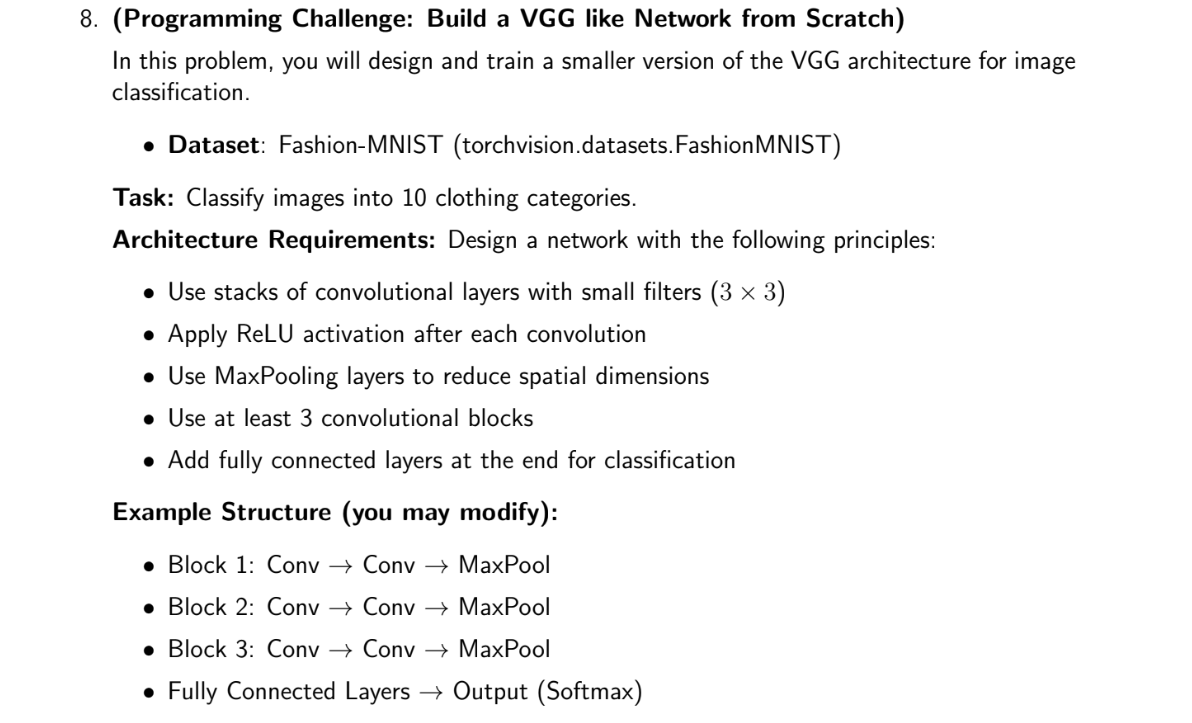

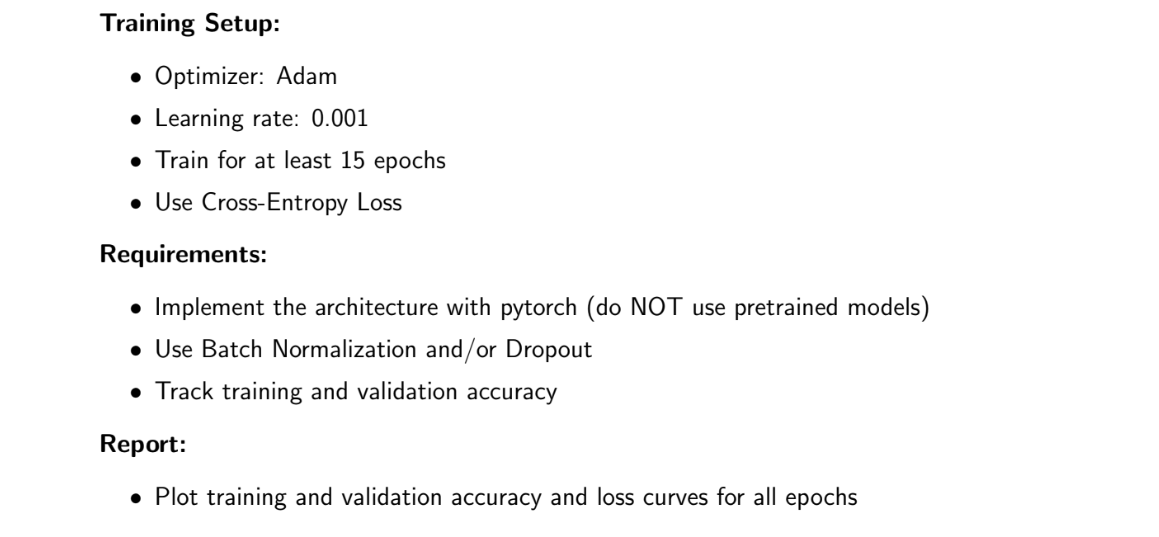

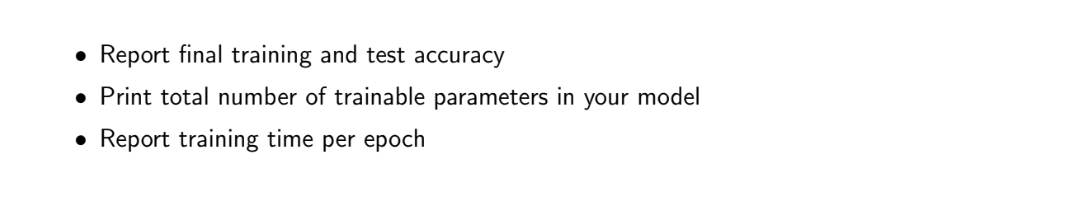

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 229kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.78MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.4MB/s]


Total Trainable Parameters: 585066
Epoch 1: Train Loss=0.4439, Train Acc=0.8404, Val Loss=0.3224, Val Acc=0.8814, Time=12.23s
Epoch 2: Train Loss=0.2759, Train Acc=0.9004, Val Loss=0.2430, Val Acc=0.9111, Time=11.52s
Epoch 3: Train Loss=0.2262, Train Acc=0.9193, Val Loss=0.2428, Val Acc=0.9112, Time=11.58s
Epoch 4: Train Loss=0.2000, Train Acc=0.9277, Val Loss=0.2116, Val Acc=0.9270, Time=11.41s
Epoch 5: Train Loss=0.1722, Train Acc=0.9384, Val Loss=0.2136, Val Acc=0.9277, Time=12.51s
Epoch 6: Train Loss=0.1525, Train Acc=0.9443, Val Loss=0.2341, Val Acc=0.9228, Time=12.29s
Epoch 7: Train Loss=0.1320, Train Acc=0.9517, Val Loss=0.2183, Val Acc=0.9287, Time=11.65s
Epoch 8: Train Loss=0.1163, Train Acc=0.9579, Val Loss=0.2282, Val Acc=0.9280, Time=11.29s
Epoch 9: Train Loss=0.1010, Train Acc=0.9630, Val Loss=0.2204, Val Acc=0.9303, Time=11.49s
Epoch 10: Train Loss=0.0864, Train Acc=0.9684, Val Loss=0.2258, Val Acc=0.9307, Time=11.46s
Epoch 11: Train Loss=0.0771, Train Acc=0.9716, Val Los

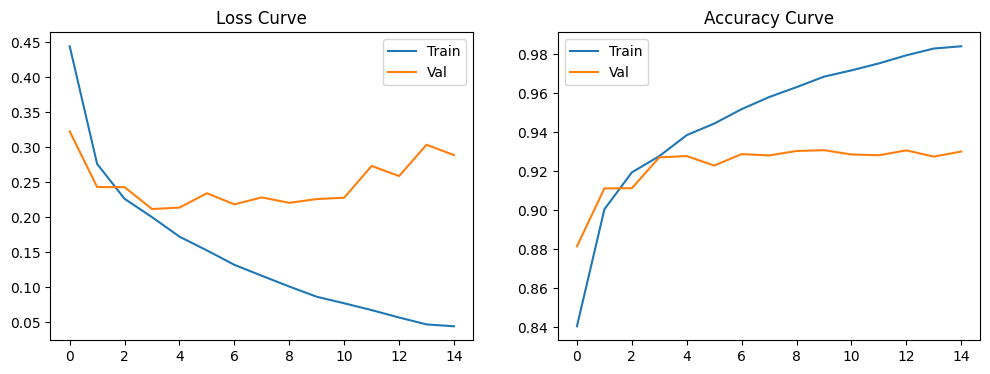

In [10]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================
# 1. DATA
# =========================================
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Split validation
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=128)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128)

# =========================================
# 2. VGG-LIKE MODEL
# =========================================
class VGGSmall(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*3*3, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = VGGSmall().to(device)

# =========================================
# 3. PARAMETER COUNT
# =========================================
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total Trainable Parameters:", total_params)

# =========================================
# 4. TRAINING SETUP
# =========================================
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epochs = 15

train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

# =========================================
# 5. TRAIN LOOP
# =========================================
for epoch in range(epochs):
    start_time = time.time()

    # TRAIN
    model.train()
    train_loss, correct, total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_loss /= len(val_loader)

    end_time = time.time()

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, "
          f"Time={end_time-start_time:.2f}s")

    train_loss_hist.append(train_loss)
    val_loss_hist.append(val_loss)
    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

# =========================================
# 6. TEST ACCURACY
# =========================================
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Final Test Accuracy:", correct/total)

# =========================================
# 7. PLOTS
# =========================================
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(train_loss_hist, label='Train')
plt.plot(val_loss_hist, label='Val')
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_acc_hist, label='Train')
plt.plot(val_acc_hist, label='Val')
plt.title("Accuracy Curve")
plt.legend()

plt.show()